In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/processed/cleaned_orders.csv')
print(df.shape)
df.head()

(180519, 39)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Profit Per Order,Order Region,Order State,Order Status,Product Card Id,Product Name,Product Price,shipping date (DateOrders),Shipping Mode,delivery_delay_days
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,91.250000,Southeast Asia,Java Occidental,COMPLETE,1360,Smart watch,327.75,2018-02-03 22:56:00,Standard Class,-1
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,-249.089996,South Asia,Rajastán,PENDING,1360,Smart watch,327.75,2018-01-18 12:27:00,Standard Class,1
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,-247.779999,South Asia,Rajastán,CLOSED,1360,Smart watch,327.75,2018-01-17 12:06:00,Standard Class,0
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,22.860001,Oceania,Queensland,COMPLETE,1360,Smart watch,327.75,2018-01-16 11:45:00,Standard Class,-1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,134.210007,Oceania,Queensland,PENDING_PAYMENT,1360,Smart watch,327.75,2018-01-15 11:24:00,Standard Class,-2


In [2]:
print(df['Delivery Status'].value_counts())

Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64


In [3]:
df_model = df[df['Delivery Status'] != 'Shipping canceled'].copy()
print("Rows before:", df.shape[0])
print("Rows after excluding cancellations:", df_model.shape[0])
print(df_model['Late_delivery_risk'].value_counts(normalize=True))

Rows before: 180519
Rows after excluding cancellations: 172765
Late_delivery_risk
1    0.5729
0    0.4271
Name: proportion, dtype: float64


In [4]:
df_model['order date (DateOrders)'] = pd.to_datetime(df_model['order date (DateOrders)'])
df_model['order_month'] = df_model['order date (DateOrders)'].dt.month
df_model['order_dayofweek'] = df_model['order date (DateOrders)'].dt.dayofweek  # 0=Monday

feature_cols = [
    'Shipping Mode',
    'Days for shipment (scheduled)',
    'Order Region',
    'Market',
    'Category Name',
    'Customer Segment',
    'Order Item Quantity',
    'Sales',
    'Order Item Discount Rate',
    'order_month',
    'order_dayofweek'
]

target_col = 'Late_delivery_risk'

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()

print(X.shape, y.shape)
print(X.dtypes)

(172765, 11) (172765,)
Shipping Mode                        str
Days for shipment (scheduled)      int64
Order Region                         str
Market                               str
Category Name                        str
Customer Segment                     str
Order Item Quantity                int64
Sales                            float64
Order Item Discount Rate         float64
order_month                        int32
order_dayofweek                    int32
dtype: object


In [5]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Shipping Mode', 'Order Region', 'Market', 'Category Name', 'Customer Segment']

X_encoded = X.copy()
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    encoders[col] = le  # save for later (SHAP plots need original labels)

print(X_encoded.dtypes)
X_encoded.head()

Shipping Mode                      int64
Days for shipment (scheduled)      int64
Order Region                       int64
Market                             int64
Category Name                      int64
Customer Segment                   int64
Order Item Quantity                int64
Sales                            float64
Order Item Discount Rate         float64
order_month                        int32
order_dayofweek                    int32
dtype: object


,Shipping Mode,Days for shipment (scheduled),Order Region,Market,Category Name,Customer Segment,Order Item Quantity,Sales,Order Item Discount Rate,order_month,order_dayofweek
0,3,4,15,3,40,0,1,327.75,0.04,1,2
1,3,4,13,3,40,0,1,327.75,0.05,1,5
2,3,4,13,3,40,0,1,327.75,0.06,1,5
3,3,4,11,3,40,2,1,327.75,0.07,1,5
4,3,4,11,3,40,1,1,327.75,0.09,1,5


In [6]:
from sklearn.model_selection import train_test_split

df_model_sorted = df_model.sort_values('order date (DateOrders)')
sorted_idx = df_model_sorted.index

X_encoded_sorted = X_encoded.loc[sorted_idx]
y_sorted = y.loc[sorted_idx]

split_point = int(len(X_encoded_sorted) * 0.8)

X_train = X_encoded_sorted.iloc[:split_point]
X_test = X_encoded_sorted.iloc[split_point:]
y_train = y_sorted.iloc[:split_point]
y_test = y_sorted.iloc[split_point:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train late rate:", y_train.mean().round(3))
print("Test late rate:", y_test.mean().round(3))

Train shape: (138212, 11)
Test shape: (34553, 11)
Train late rate: 0.573
Test late rate: 0.573


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_lr), 3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.61      0.85      0.71     14759
           1       0.84      0.59      0.69     19794

    accuracy                           0.70     34553
   macro avg       0.72      0.72      0.70     34553
weighted avg       0.74      0.70      0.70     34553

ROC-AUC: 0.733

Confusion Matrix:
[[12519  2240]
 [ 8156 11638]]


In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.59      0.90      0.72     14759
           1       0.88      0.54      0.67     19794

    accuracy                           0.70     34553
   macro avg       0.74      0.72      0.69     34553
weighted avg       0.76      0.70      0.69     34553

ROC-AUC: 0.741

Confusion Matrix:
[[13303  1456]
 [ 9058 10736]]


In [9]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_xgb), 3))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.60      0.89      0.71     14759
           1       0.87      0.55      0.68     19794

    accuracy                           0.70     34553
   macro avg       0.73      0.72      0.69     34553
weighted avg       0.75      0.70      0.69     34553

ROC-AUC: 0.739

Confusion Matrix:
[[13118  1641]
 [ 8871 10923]]


## Interpretation
If the cost of a missed late-delivery (false negative) is high — e.g. losing a customer relationship, needing to expedite a replacement — Logistic Regression's higher recall (59% vs 54-55%) makes it the safer choice despite its "weaker" precision.
If the cost of a false alarm is high — e.g. flooding operations teams with unnecessary alerts, causing alert fatigue — Random Forest's higher precision (88% vs 84%) is preferable.
Given that in most supply chain contexts, missing a real risk is more costly than an extra warning, I'd lean toward Logistic Regression or a threshold-adjusted XGBoost as the production choice.

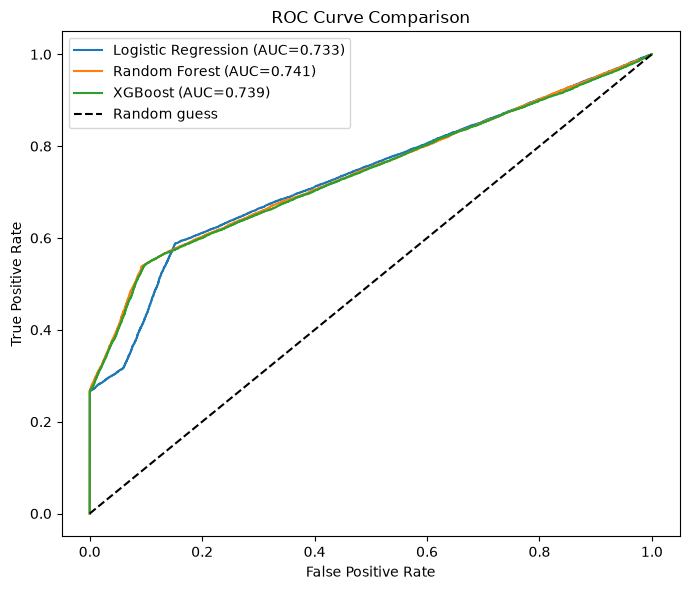

In [10]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, y_proba_xgb):.3f})')
plt.plot([0,1],[0,1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('../powerbi/roc_curve_comparison.png')
plt.show()

In [11]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

d:\supply-chain-risk\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (34553, 11)


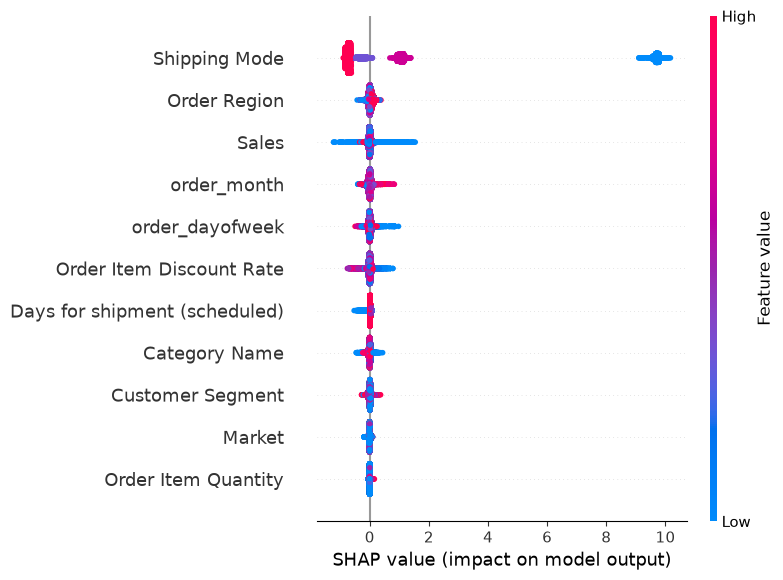

In [12]:
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, show=False)
plt.tight_layout()
plt.savefig('../powerbi/shap_summary.png', bbox_inches='tight')
plt.show()

In [13]:
print(encoders['Shipping Mode'].classes_)

['First Class' 'Same Day' 'Second Class' 'Standard Class']


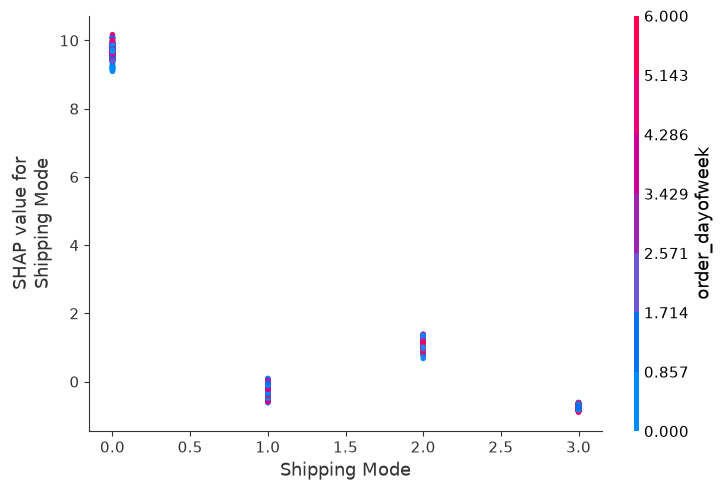

In [14]:
shap.dependence_plot('Shipping Mode', shap_values, X_test, feature_names=X_test.columns, show=False)
plt.tight_layout()
plt.savefig('../powerbi/shap_dependence_shipping_mode.png', bbox_inches='tight')
plt.show()

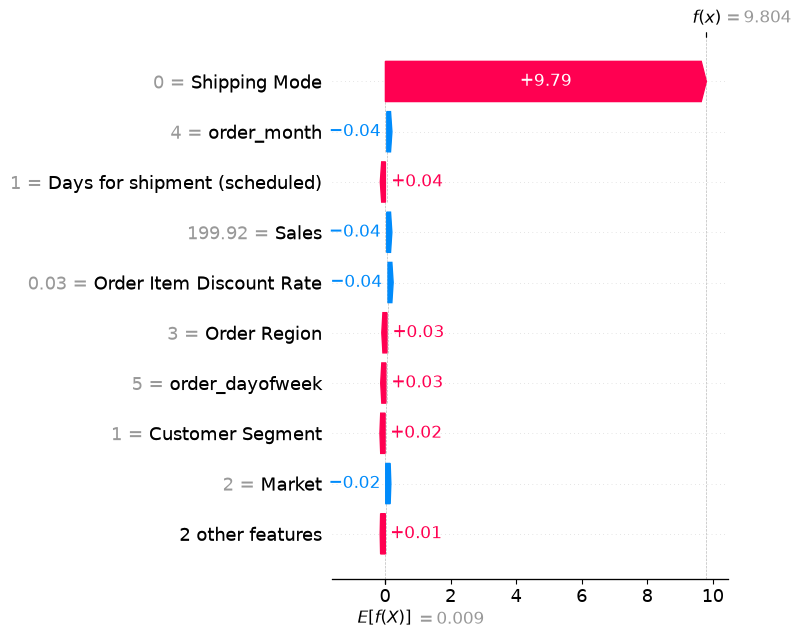

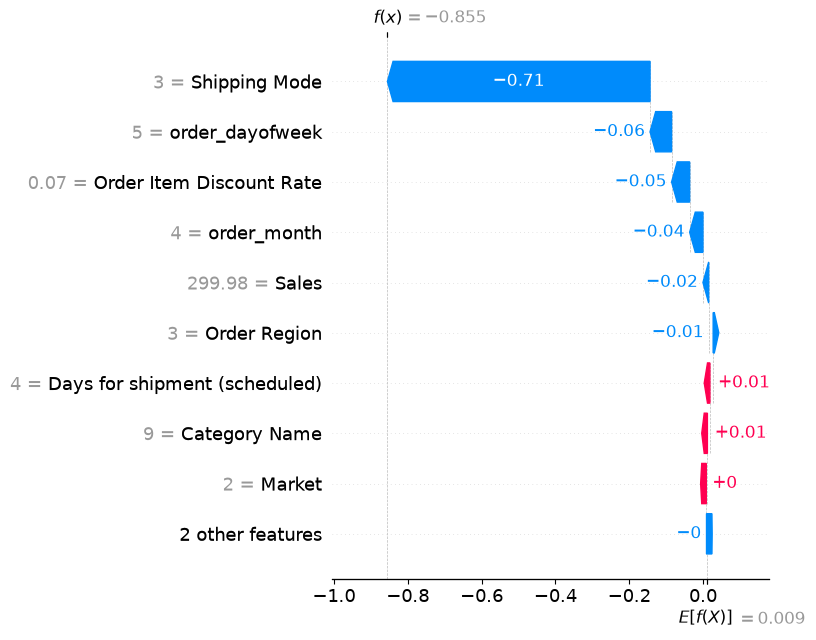

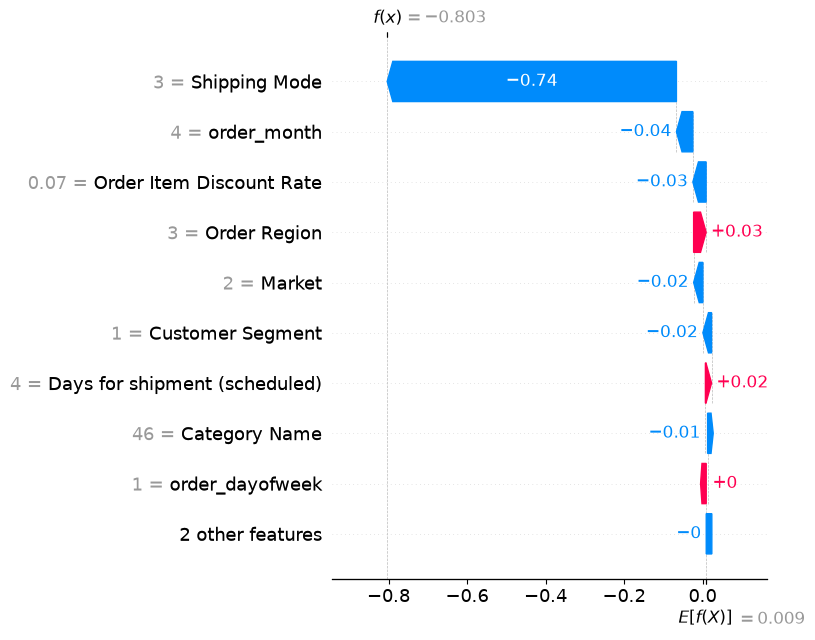

In [15]:
sample_idx = [0, 100, 500]  

for i in sample_idx:
    shap.plots.waterfall(shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_test.iloc[i],
        feature_names=X_test.columns.tolist()
    ), show=False)
    plt.tight_layout()
    plt.savefig(f'../powerbi/shap_waterfall_order_{i}.png', bbox_inches='tight')
    plt.show()

In [16]:
import joblib

joblib.dump(xgb, '../src/model.pkl')
joblib.dump(encoders, '../src/encoders.pkl')
joblib.dump(explainer, '../src/shap_explainer.pkl')
joblib.dump(feature_cols, '../src/feature_cols.pkl')

print("Saved model, encoders, explainer, and feature list to src/")

Saved model, encoders, explainer, and feature list to src/


## Modeling Summary
- Compared Logistic Regression, Random Forest, and XGBoost for late-delivery risk prediction
- All three performed similarly (~70% accuracy, 0.73-0.74 AUC), suggesting the underlying 
  signal is largely linear rather than requiring complex non-linear modeling
- Key tradeoff: Logistic Regression has better recall (catches more true late orders), 
  Random Forest/XGBoost have better precision (fewer false alarms) — model choice should 
  depend on business cost of missed risk vs alert fatigue
- SHAP analysis on XGBoost confirms Shipping Mode as the overwhelmingly dominant risk 
  driver, consistent with EDA findings — First Class shipments push risk sharply up, 
  Standard Class pushes it down, with all other features playing a comparatively minor role